In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()

# === Machine Learning Models ===
from catboost import CatBoostClassifier

In [3]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [2]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [3]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# CatBoost Classifier

## a. Training

In [4]:
# --- CatBoost Classifier ---
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    random_seed=42,
    eval_metric='F1',
    class_weights=[1, 1.5],      # nếu class 1 hiếm hơn thì tăng trọng số
    verbose=100,
    thread_count=-1
)

# --- Training ---
cat_model.fit(X_train, y_train)

0:	learn: 0.5808256	total: 1s	remaining: 8m 20s
100:	learn: 0.6059709	total: 1m 11s	remaining: 4m 42s
200:	learn: 0.6142633	total: 3m 54s	remaining: 5m 48s
300:	learn: 0.6187395	total: 6m 58s	remaining: 4m 36s
400:	learn: 0.6219289	total: 8m 48s	remaining: 2m 10s
499:	learn: 0.6246097	total: 10m 2s	remaining: 0us


## b. Predicting & Evaluating

### Dev

Evaluation on  set:
Accuracy : 0.6373
Precision: 0.5154
Recall   : 0.7193
F1-score : 0.6005
ROC AUC  : 0.7165


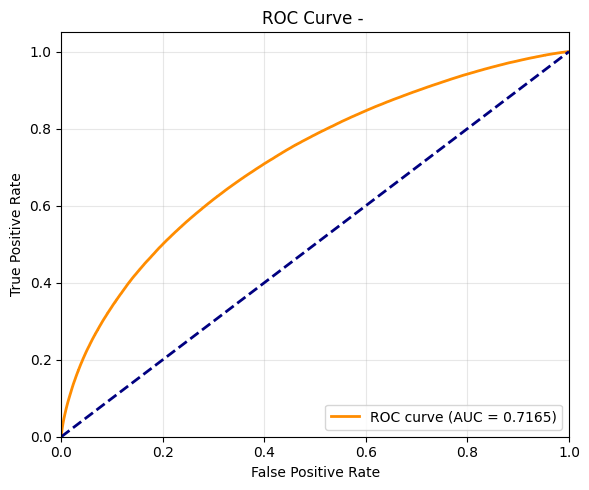

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67    837529
           1       0.52      0.72      0.60    511152

    accuracy                           0.64   1348681
   macro avg       0.64      0.65      0.63   1348681
weighted avg       0.68      0.64      0.64   1348681



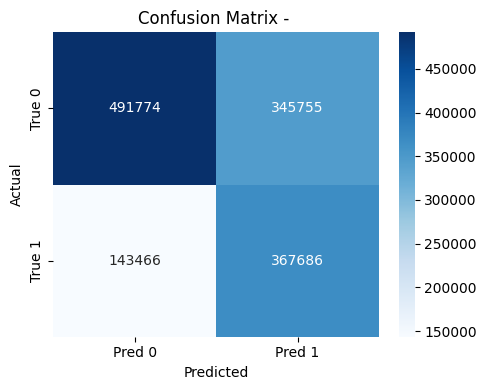

Best threshold: 0.50 with F1-score: 1.0000


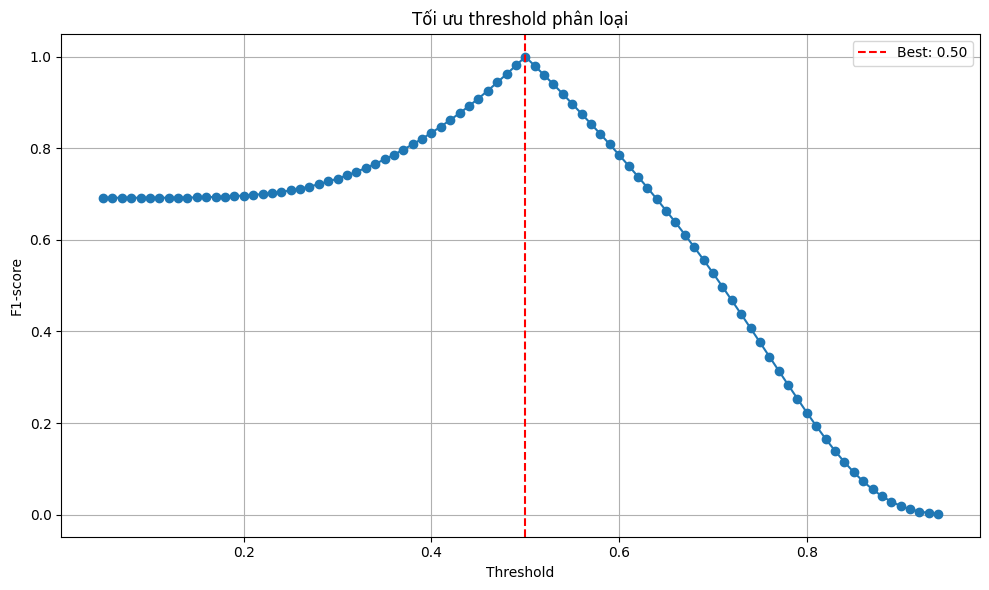

(np.float64(0.5000000000000001), 1.0)

In [7]:
# --- Predicting ---
y_pred_dev = cat_model.predict(X_dev)
y_proba_dev = cat_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (cat_model, X_dev, y_pred_dev)

### Test

Evaluation on  set:
Accuracy : 0.6378
Precision: 0.5158
Recall   : 0.7202
F1-score : 0.6011
ROC AUC  : 0.7172


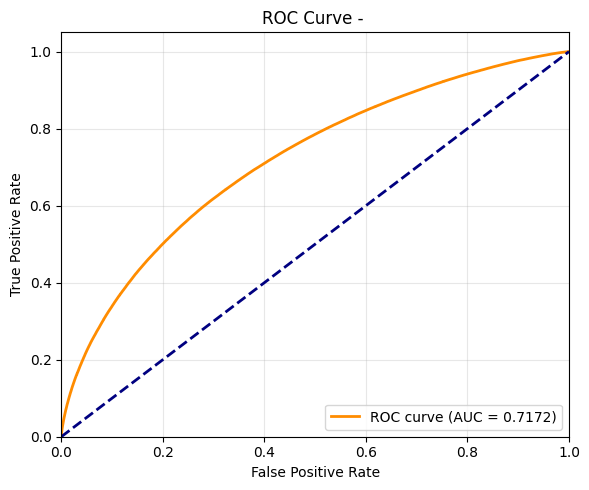

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67    837529
           1       0.52      0.72      0.60    511152

    accuracy                           0.64   1348681
   macro avg       0.65      0.65      0.63   1348681
weighted avg       0.68      0.64      0.64   1348681



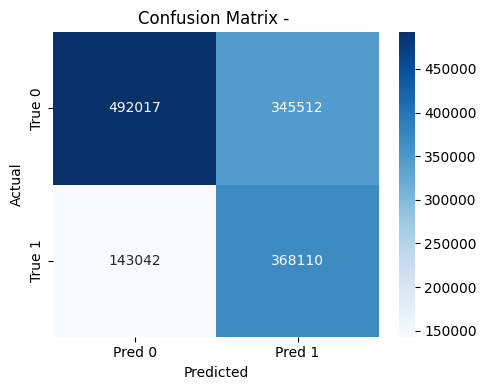

Best threshold: 0.50 with F1-score: 1.0000


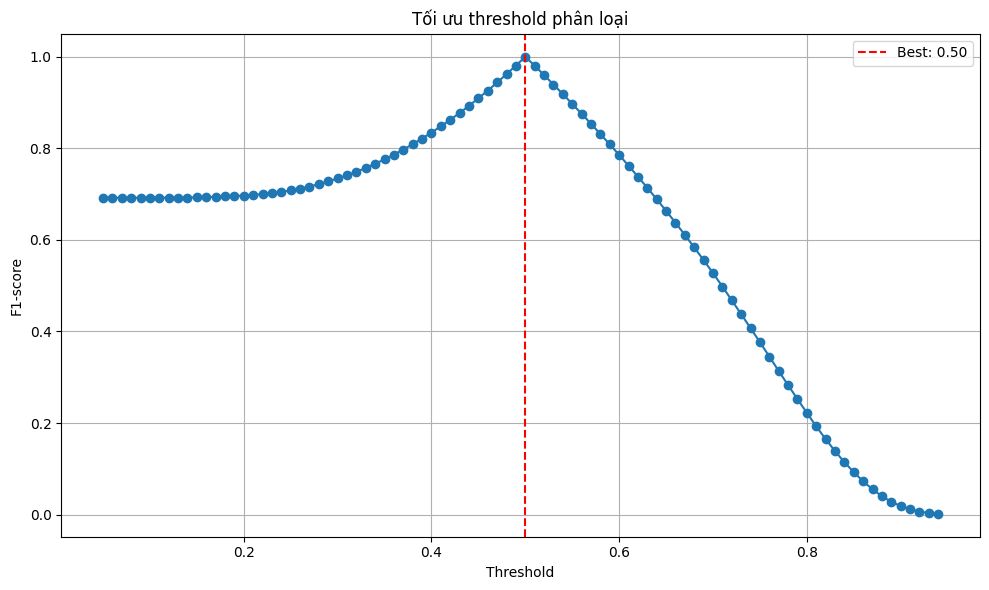

(np.float64(0.5000000000000001), 1.0)

In [8]:
# --- Predicting ---
y_pred_test = cat_model.predict(X_test)
y_proba_test = cat_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (cat_model, X_test, y_pred_test)